<a href="https://colab.research.google.com/github/Donthula-Harika/Data_Analysis_Assignments/blob/main/Assignment_1(Real_Estate_Market_Insights).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task  -REAL ESTATE MARKET INSIGHTS

##Task 1 — Load & Inspect the

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
df = pd.read_csv('/content/drive/MyDrive/Data Sets/Bengaluru_House_Data.csv')

In [43]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [44]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [45]:
df.shape

(13320, 9)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [47]:
df.dtypes

,0
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64


## Task 2 — Clean the Dataset

In [48]:
# Identify and count missing values in each column.
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [49]:
#Drop column(s) that are irrelevant for price analysis (example: society or unnamed columns).
df.drop(['society'], axis=1, inplace=True)


In [30]:
print(df.isnull().sum())
print(df.shape)

area_type         0
availability      0
location          1
size             16
total_sqft        0
bath             73
balcony         609
price             0
dtype: int64
(13320, 8)


In [50]:
#Handle missing values in numeric columns such as bath, balcony, etc. (use either dropna() or fillna() depending on your reasoning).
df.dropna(subset=['bath', 'balcony'], inplace=True)


- Drop Rows (When Missing Data Is Small)
- Fill with Median (When Data Loss Is Risky)

In [51]:
print(df.isnull().sum())
print(df.shape)

area_type       0
availability    0
location        1
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64
(12711, 8)


In [52]:
df.dtypes

,0
area_type,object
availability,object
location,object
size,object
total_sqft,object
bath,float64
balcony,float64
price,float64


- Here total_sqft id object time
but it should be float
- Reason: It has valuses like 2100 - 2850
- Convert these range into float values
- "2100 - 2850" is text, not a number → ML cannot understand it.

In [53]:
#Convert total_sqft to numeric — handle values like "2100 - 2850" by converting them to an average or a single number.
def convert_sqft(val):
    try:
        if '-' in val:
            a, b = val.split('-')
            return (float(a) + float(b)) / 2
        return float(val)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)


In [54]:
df['total_sqft'].dtype

dtype('float64')

In [55]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,0
total_sqft,42
bath,0
balcony,0
price,0


In [56]:
df.dropna(subset=['total_sqft'],inplace=True)



In [63]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [65]:
# remove null valuse of location
df.dropna(subset=['location'],inplace=True)

In [66]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [58]:
# Remove duplicate rows.
df.drop_duplicates(inplace=True)


In [59]:
df.shape

(12105, 8)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12105 entries, 0 to 13318
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12105 non-null  object 
 1   availability  12105 non-null  object 
 2   location      12104 non-null  object 
 3   size          12105 non-null  object 
 4   total_sqft    12105 non-null  float64
 5   bath          12105 non-null  float64
 6   balcony       12105 non-null  float64
 7   price         12105 non-null  float64
dtypes: float64(4), object(4)
memory usage: 851.1+ KB


Index: 12105 entries, 0 to 13318
- Reset the DataFrame Index After Cleaning

In [61]:
df.reset_index(drop=True, inplace=True)


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12105 entries, 0 to 12104
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     12105 non-null  object 
 1   availability  12105 non-null  object 
 2   location      12104 non-null  object 
 3   size          12105 non-null  object 
 4   total_sqft    12105 non-null  float64
 5   bath          12105 non-null  float64
 6   balcony       12105 non-null  float64
 7   price         12105 non-null  float64
dtypes: float64(4), object(4)
memory usage: 756.7+ KB


RangeIndex: 12105 entries, 0 to 12104

##Task 3

In [67]:
#unique locations
print(df['location'].unique())
print("\ncount is:" )
df['location'].nunique()

['Electronic City Phase II' 'Chikka Tirupathi' 'Uttarahalli' ...
 '12th cross srinivas nagar banshankari 3rd stage' 'Havanur extension'
 'Abshot Layout']

count is:


1259

In [68]:
#avg house price for each location
df.groupby('location')['price'].mean()

,price
location,
Anekal,16.000000
Banaswadi,35.000000
Basavangudi,50.000000
Bhoganhalli,22.890000
Devarabeesana Halli,124.833333
...,...
singapura paradise,140.000000
t.c palya,160.000000
tc.palya,60.750000


In [69]:
#highest avg price location
df.groupby('location')['price'].mean().idxmax()

'Ashok Nagar'

In [72]:
avg_price = df.groupby('location')['price'].mean().sort_values(ascending=False)
top_loc = avg_price.idxmax()
top_price = avg_price.max()
print(f"\n3) Highest average price location: {top_loc} — {top_price:.2f} lakhs")


3) Highest average price location: Ashok Nagar — 1486.00 lakhs


In [73]:
#corelation btw total_sqft,price,bath
df[['total_sqft','price','bath']].corr()

,total_sqft,price,bath
total_sqft,1.000000,0.556720,0.390779
price,0.556720,1.000000,0.455601
bath,0.390779,0.455601,1.000000


In [75]:

# 5) Interpretation (simple logic)
corr = df[['total_sqft', 'bath', 'price']].corr()
corr_sqft_price = corr.loc['total_sqft', 'price']
print("\n5) Interpretation:")

if corr_sqft_price > 0.7:
    print("• Strong positive correlation → Larger houses generally have higher prices.")
elif corr_sqft_price > 0.4:
    print("• Moderate correlation → Larger houses often cost more, but not always.")
else:
    print("• Weak correlation → Size alone does NOT determine price.")



5) Interpretation:
• Moderate correlation → Larger houses often cost more, but not always.


##Task 4 — Data Visualization

<Axes: xlabel='price', ylabel='Density'>

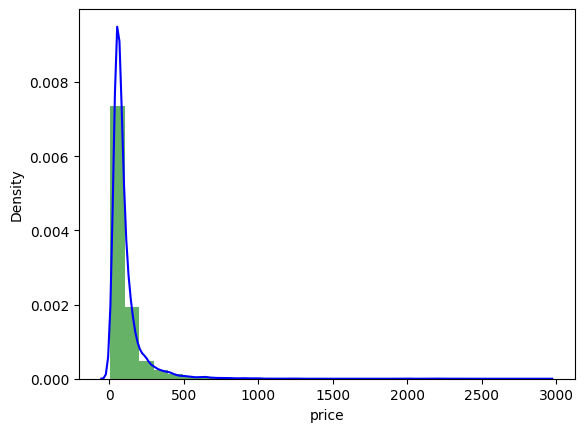

In [76]:
#Plot the distribution of the price column using a Histogram + KDE curve.
plt.hist(df['price'], bins=30, density=True, alpha=0.6, color='g')
sns.kdeplot(df['price'], color='b')

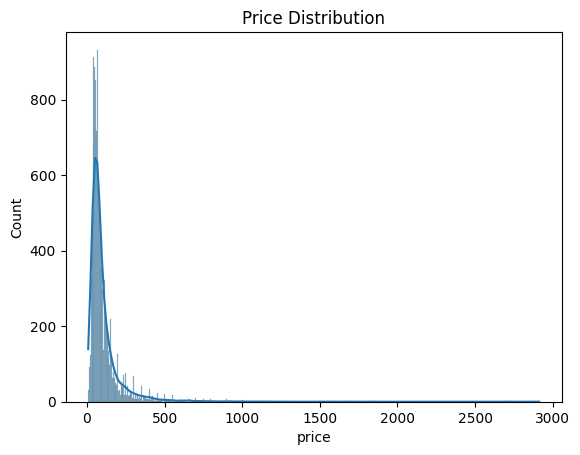

In [79]:

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()


Text(0, 0.5, 'price')

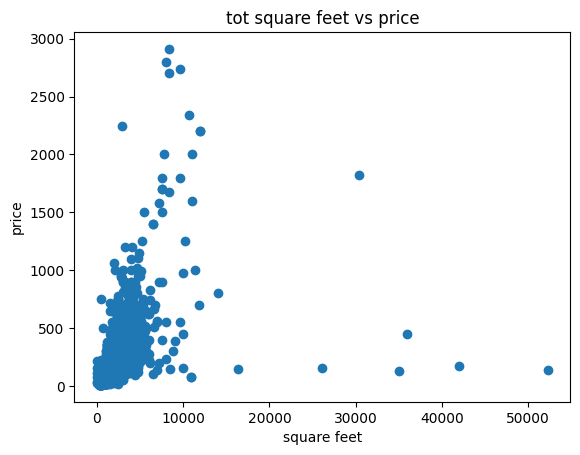

In [77]:
#Visualize the relationship between total_sqft and price using a Scatter Plot.
plt.scatter(df['total_sqft'],df['price'])
plt.title("tot square feet vs price")
plt.xlabel("square feet")
plt.ylabel("price")

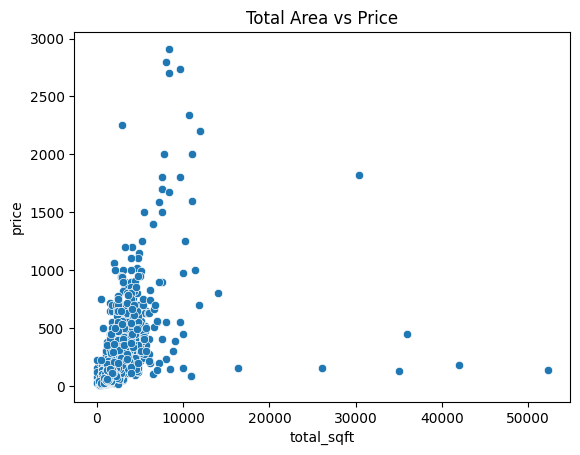

In [80]:
sns.scatterplot(x=df['total_sqft'], y=df['price'])
plt.title("Total Area vs Price")
plt.show()

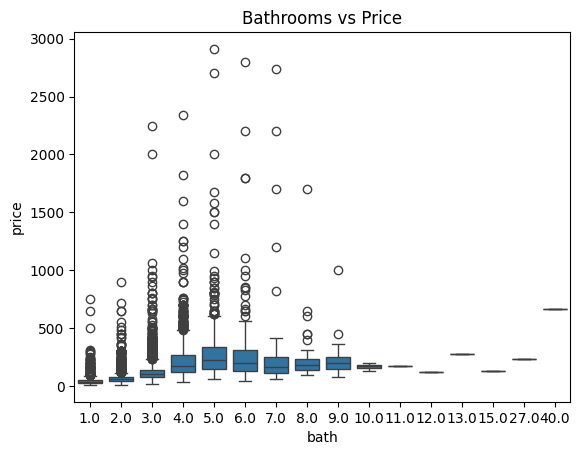

In [82]:
#Show how bath count affects house prices using a Box Plot.
sns.boxplot(x=df['bath'], y=df['price'])
plt.title("Bathrooms vs Price")
plt.show()


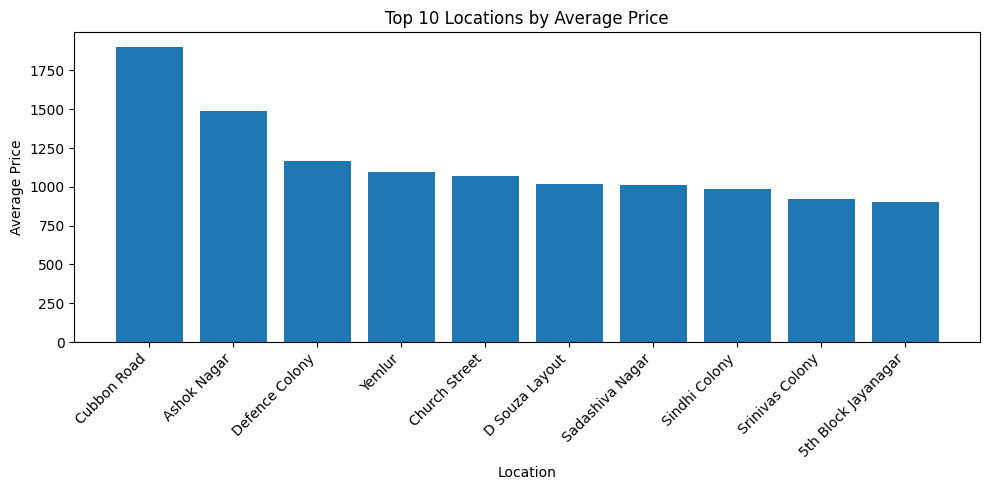

In [ ]:
#Plot the Top 10 locations with highest average price using a Bar Chart.

# compute top 10
top10 = (
    df.groupby('location')['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

# plot
plt.figure(figsize=(10,5))
plt.bar(top10.index, top10.values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Location")
plt.ylabel("Average Price")
plt.title("Top 10 Locations by Average Price")
plt.tight_layout()
plt.show()


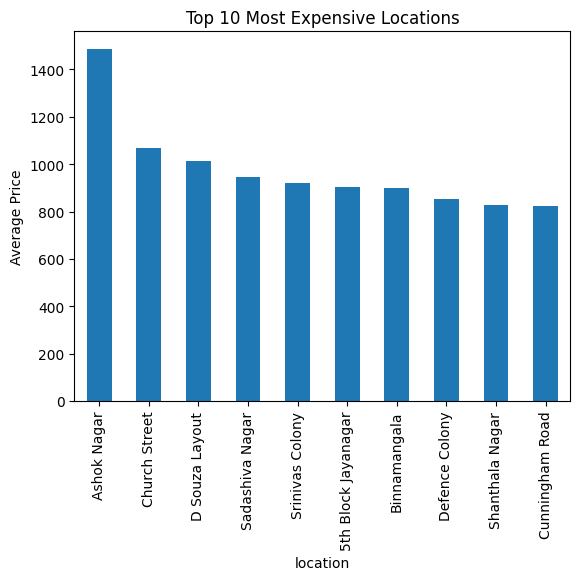

In [83]:
top_locs = df.groupby('location')['price'].mean().sort_values(ascending=False).head(10)

top_locs.plot(kind='bar')
plt.title("Top 10 Most Expensive Locations")
plt.ylabel("Average Price")
plt.show()


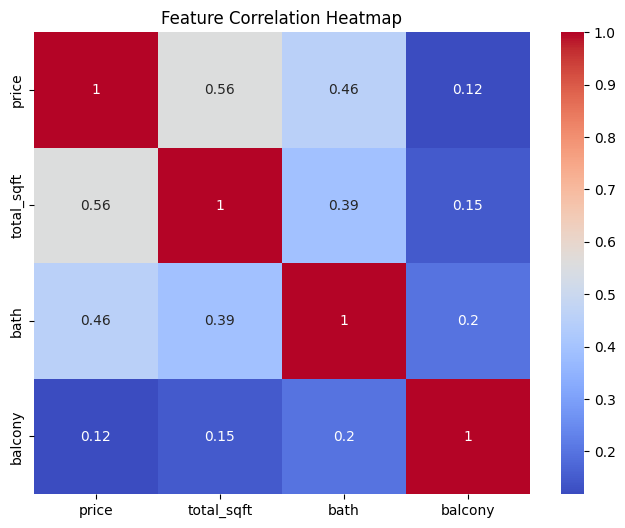

In [85]:
# Create a Heatmap to visualize correlations among numeric features (price, total_sqft, bath, balcony, etc.).
plt.figure(figsize=(8,6))
sns.heatmap(df[['price','total_sqft','bath','balcony']].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


##Task 5


In [86]:
df.to_csv("cleaned_bengaluru_houses_data.csv", index=False)
from google.colab import files
files.download("cleaned_bengaluru_houses_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
new_df = pd.read_csv('cleaned_bengaluru_houses_data.csv')
print(new_df.head())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   total_sqft  bath  balcony   price  
0      1056.0   2.0      1.0   39.07  
1      2600.0   5.0      3.0  120.00  
2      1440.0   2.0      3.0   62.00  
3      1521.0   3.0      1.0   95.00  
4      1200.0   2.0      1.0   51.00  
